In [1]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("kandeelai22/messy-e-commerce-sales-dataset")

# print("Path to dataset files:", path)

In [2]:
dataset_link = 'https://www.kaggle.com/datasets/kandeelai22/messy-e-commerce-sales-dataset/data'

### 1. Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder,
    LabelEncoder, FunctionTransformer, PolynomialFeatures
)
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries imported!")

✓ Libraries imported!


### 2. Load and Explore Data

In [4]:
raw_df = pd.read_csv("messy_ecommerce_sales_data.csv")

In [5]:
raw_df.shape

(103, 11)

In [6]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103 entries, 0 to 102
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ID              103 non-null    int64  
 1    Customer_Name  103 non-null    object 
 2   Order_ID        103 non-null    object 
 3   Order_Date      103 non-null    object 
 4   Product         103 non-null    object 
 5    Category       95 non-null     object 
 6   Quantity        98 non-null     object 
 7   Price           98 non-null     object 
 8   Payment_Method  103 non-null    object 
 9   Status          103 non-null    object 
 10  Total           89 non-null     float64
dtypes: float64(1), int64(1), object(9)
memory usage: 9.0+ KB


In [7]:
raw_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,103.0,149.640777,28.704326,100.0,125.50,149.00,174.5,199.0
Total,89.0,1232.949101,2605.471455,-20000.0,582.13,1138.76,2153.4,4722.7


In [10]:
raw_df.describe(include = 'object').T

,count,unique,top,freq
Customer_Name,103,100,Customer_146,2
Order_ID,103,100,ORD-32755,2
Order_Date,103,86,2/9/2025,4
Product,103,21,Blender,8
Category,95,9,Books,22
Quantity,98,8,5,25
Price,98,94,abd,2
Payment_Method,103,4,Cash on Delivery,33
Status,103,5,Processing,27


In [11]:
raw_df.dtypes

ID                  int64
 Customer_Name     object
Order_ID           object
Order_Date         object
Product            object
 Category          object
Quantity           object
Price              object
Payment_Method     object
Status             object
Total             float64
dtype: object

#### Checking presence of outliers

In [12]:
data_iqr = raw_df['Total']

iqr = data_iqr.quantile(0.75) - data_iqr.quantile(0.25)
lower_bound = data_iqr.quantile(0.25) - 1.5 * iqr
upper_bound = data_iqr.quantile(0.75) + 1.5 * iqr

# data_iqr[(data_iqr > upper_bound) | (data_iqr < lower_bound)].shape[0]
raw_df[(data_iqr > upper_bound) | (data_iqr < lower_bound)]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total
17,117,Customer_117,ORD-72751,2/12/2025,Blender,electronic,-2,10000,Cash on Delivery,Processing,-20000.00
34,134,Customer_134,ORD-16585,10/4/2025,T-shirt,Clothing,-5,591.53,PayPal,Shipped,-2957.65
94,194,Customer_194,ORD-69764,2/10/2025,Lamp,Home,5,944.54,Cash on Delivery,Returned,4722.70


In [13]:
missing = raw_df.isnull().sum()
missing_percentage = (missing / len(raw_df) * 100).round(2)
audit = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percentage})
audit[audit['Missing %'] > 0]

,Missing Count,Missing %
Category,8,7.77
Quantity,5,4.85
Price,5,4.85
Total,14,13.59


### 3. Data Cleaning

In [14]:
df_clean = raw_df.copy()

#### (a) Removing extra space from column names

In [15]:
df_clean.columns = df_clean.columns.str.strip()

#### (b) Standardizing Category column

In [16]:
df_clean['Category'].str.strip().str.title().value_counts()

Category
Books          22
Home           20
Electronics    17
Sports         17
Clothing       15
Electronic      4
Name: count, dtype: int64

In [17]:
df_clean['Category'] = df_clean['Category'].str.strip().str.title()

In [18]:
category_map = {
    'Sports': 'Sports',
    'Electronic': 'Electronics',
    'Electronics': 'Electronics',
    'NaN': np.nan
}

In [19]:
df_clean['Category'] = df_clean['Category'].replace(category_map)

In [20]:
df_clean['Category'].value_counts()

Category
Books          22
Electronics    21
Home           20
Sports         17
Clothing       15
Name: count, dtype: int64

#### (c) Cleaning Price column

In [21]:
df_clean['Price'] = pd.to_numeric(df_clean['Price'], errors = 'coerce')

In [22]:
df_clean['Price'] = df_clean['Price'].astype(str).str.replace('$', '').str.replace(',', '').astype(float)

In [23]:
# remove any negative price
df_clean = df_clean[~(df_clean['Price'] < 0)]

#### (d) Cleaning Total column

In [24]:
def parse_total(value):
    # check if value is string
    if isinstance(value, str):
        cleaned = value.replace('$', '').replace(',','')
        try:
            return float(cleaned)
        except ValueError:
            return np.nan 
    # check if value is int or float
    elif isinstance(value, (int, float)):
        return value
    else:
        return np.nan

df_clean['Total'] = df_clean['Total'].apply(parse_total)

In [25]:
# remove any negative total
df_clean = df_clean[~(df_clean['Total'] < 0)]

#### (e) Cleaning Quantity Column

In [26]:
df_clean['Quantity'] = pd.to_numeric(df_clean['Quantity'].astype(str).str.extract(r'(-?\d+)', expand=False), errors='coerce')

In [27]:
df_clean = df_clean[~(df_clean['Quantity'] < 0)]

#### (f) Cleaning Order Date

In [28]:
df_clean['Order_Date'].sample()[:15]

74    9/20/2025
Name: Order_Date, dtype: object

In [29]:
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], errors='coerce')
df_clean = df_clean[df_clean['Order_Date'].notna()]

In [30]:
df_clean['Year'] = df_clean['Order_Date'].dt.year
df_clean['Month'] = df_clean['Order_Date'].dt.month
df_clean['Day'] = df_clean['Order_Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Order_Date'].dt.dayofweek

In [31]:
df_clean['Order_Date'].unique()[:15]

<DatetimeArray>
['2024-11-22 00:00:00', '2025-07-05 00:00:00', '2024-12-23 00:00:00',
 '2025-03-19 00:00:00', '2025-10-20 00:00:00', '2024-11-20 00:00:00',
 '2025-02-02 00:00:00', '2025-01-03 00:00:00', '2025-10-23 00:00:00',
 '2025-05-03 00:00:00', '2025-09-26 00:00:00', '2025-10-22 00:00:00',
 '2025-03-02 00:00:00', '2025-07-24 00:00:00', '2025-01-10 00:00:00']
Length: 15, dtype: datetime64[ns]

In [32]:
df_clean[df_clean['Order_Date'].isna()]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total,Year,Month,Day,DayOfWeek


#### (g) Cleaning Order ID

In [33]:
df_clean[df_clean.duplicated(subset=['Order_ID'], keep=False)]

,ID,Customer_Name,Order_ID,Order_Date,Product,Category,Quantity,Price,Payment_Method,Status,Total,Year,Month,Day,DayOfWeek
42,142,Customer_142,ORD-69018,2025-10-30,Shoes,Clothing,5.0,645.26,Credit Card,Shipped,2258.410,2025,10,30,3
46,146,Customer_146,ORD-32755,2025-07-09,Basketball,Electronics,2.0,705.42,Bank Transfer,Processing,1410.840,2025,7,9,2
75,175,Customer_175,ORD-56651,2025-02-24,Headphones,Electronics,1.0,111.36,Credit Card,Processing,111.360,2025,2,24,0
100,175,Customer_175,ORD-56651,2025-02-24,Headphones,Electronics,1.0,111.36,Credit Card,Processing,77.952,2025,2,24,0
101,142,Customer_142,ORD-69018,2025-10-30,Shoes,Clothing,5.0,645.26,Credit Card,Shipped,3226.300,2025,10,30,3
102,146,Customer_146,ORD-32755,2025-07-09,Basketball,Electronics,2.0,705.42,Bank Transfer,Processing,1410.840,2025,7,9,2


In [34]:
df_clean['Order_ID'].value_counts()[df_clean['Order_ID'].value_counts() > 1]

Order_ID
ORD-56651    2
ORD-32755    2
ORD-69018    2
Name: count, dtype: int64

In [35]:
df_clean = df_clean.drop_duplicates(subset=['Order_ID'], keep = 'first')

In [36]:
df_clean['Order_ID'].value_counts()[df_clean['Order_ID'].value_counts() > 1]

Series([], Name: count, dtype: int64)

### 4. Handling Missing Values

In [37]:
X = df_clean[['Price', 'Quantity']].copy()
y = df_clean['Total'].copy()

In [38]:
X.isnull().sum()

Price       9
Quantity    5
dtype: int64

In [39]:
y.isnull().sum()

np.int64(13)

In [40]:
X.shape, y.shape

((95, 2), (95,))

In [41]:
# There are two options 

# 1. mask
mask = ~y.isnull()
X_clean = X[mask]
y_clean = y[mask]

# 2.Impute missing values in features
imputer = SimpleImputer(strategy = 'median')
X_imputed = imputer.fit_transform(X_clean)

print(f"After dropping missing target: {len(y_clean)} samples")
print(f"After imputation: {np.isnan(X_imputed).sum()} missing values in X")

After dropping missing target: 82 samples
After imputation: 0 missing values in X


### 5. Feature Scaling

In [42]:
# Standard Scalar 
scalar_standard = StandardScaler()
X_standard = scalar_standard.fit_transform(X_imputed)

print("StandardScaler:")
print(f"  Mean: {X_standard.mean(axis=0)}")
print(f"  Std: {X_standard.std(axis=0)}")

StandardScaler:
  Mean: [-2.20690674e-16 -5.41572207e-18]
  Std: [1. 1.]


In [45]:
# MinMaxScalar 
scalar_minmax = MinMaxScaler()
X_minmax = scalar_minmax.fit_transform(X_imputed)

print("MinMaxScaler:")
print(f"  Min: {X_minmax.min(axis=0)}")
print(f"  Max: {X_minmax.max(axis=0)}")


MinMaxScaler:
  Min: [0. 0.]
  Max: [1. 1.]


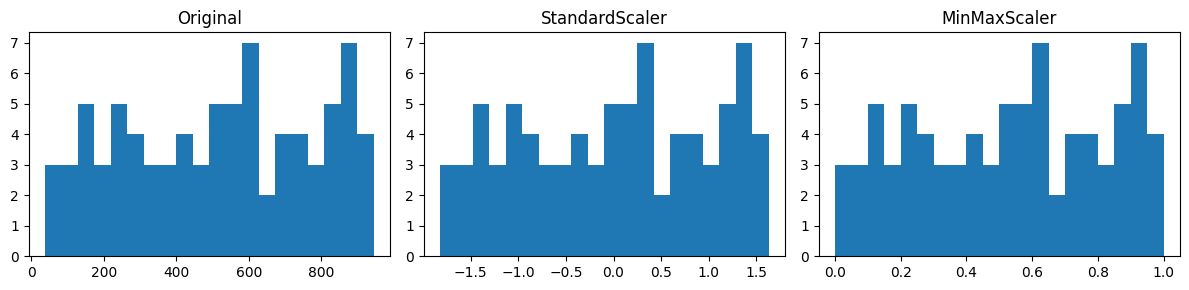

In [46]:
# Visualize scaling
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].hist(X_imputed[:, 0], bins=20)
axes[0].set_title('Original')
axes[1].hist(X_standard[:, 0], bins=20)
axes[1].set_title('StandardScaler')
axes[2].hist(X_minmax[:, 0], bins=20)
axes[2].set_title('MinMaxScaler')
plt.tight_layout()
plt.show()

### 6. Categorical Encoding

In [48]:
cat_cols = ['Category', 'Payment_Method', 'Status']

# OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_cat_ohe = ohe.fit_transform(df_clean[cat_cols].fillna('Missing'))

print(f"OneHotEncoder:")
print(f"  Categories: {ohe.categories_}")
print(f"  Output shape: {X_cat_ohe.shape}")


OneHotEncoder:
  Categories: [array(['Books', 'Clothing', 'Electronics', 'Home', 'Missing', 'Sports'],
      dtype=object), array(['Bank Transfer', 'Cash on Delivery', 'Credit Card', 'PayPal'],
      dtype=object), array(['Cancelled', 'Delivered', 'Processing', 'Returned', 'Shipped'],
      dtype=object)]
  Output shape: (95, 15)


In [50]:
# OrdinalEncoder for Status
status_order = [['Processing', 'Shipped', 'Delivered', 'Returned', 'Cancelled']]
ord_enc = OrdinalEncoder(categories = status_order)
X_status_ord = ord_enc.fit_transform(df_clean[['Status']].fillna('Processing'))

print(f"\nOrdinalEncoder for Status:")
print(f"  Encoded values sample: {X_status_ord[:5].flatten()}")


OrdinalEncoder for Status:
  Encoded values sample: [1. 0. 2. 0. 0.]


### 7. ColumnTransformer

In [53]:
numeric_features = ['Price', 'Quantity']
categorical_features = ['Category', 'Payment_Method']

# Create ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),

        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value = 'Missing')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_features)
    ], 
    remainder='drop' # Drop columns not specified
)

# Apply to Data
X_processed = preprocessor.fit_transform(df_clean)

print(f" ColumnTransformer applied")
print(f" Output shape: {X_processed.shape}")
print(f" Feature names: {preprocessor.get_feature_names_out()[:5]}...")

 ColumnTransformer applied
 Output shape: (95, 12)
 Feature names: ['num__Price' 'num__Quantity' 'cat__Category_Books'
 'cat__Category_Clothing' 'cat__Category_Electronics']...


### 8. Feature Selection

In [55]:
# VarianceThreshold 
selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X_processed)

print(f"VarianceThreshold:")
print(f"  Original: {X_processed.shape[1]} features")
print(f"  After variance threshold: {X_var.shape[1]} features")

VarianceThreshold:
  Original: 12 features
  After variance threshold: 12 features


In [59]:
# SelectKBest
X_processed_aligned = preprocessor.fit_transform(df_clean[mask]) 
selector_kbest = SelectKBest(f_regression, k = 5)
X_kbest = selector_kbest.fit_transform(X_processed_aligned, y_clean)

print(f"SelectKBest (k=5):")
print(f"  Scores: {selector_kbest.scores_[:10]}...")
print(f"  Selected {X_kbest.shape[1]} features")

SelectKBest (k=5):
  Scores: [6.52911481e+01 7.42022855e+01 1.13655475e+00 4.67685789e+00
 1.79168715e+00 1.05525567e-03 1.64422388e+00 5.52548592e-01
 7.79213307e+00 3.71528288e-03]...
  Selected 5 features


### 9. Pipeline Construction

In [61]:
# Split data
df_clean_filtered = df_clean[mask].copy()

X_train, X_test, y_train, y_test = train_test_split(
    df_clean_filtered, y_clean, test_size=0.2, random_state=1234
)

In [63]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('feature_selection', SelectKBest(f_regression, k = 5)),
    ('regressor', RandomForestRegressor(n_estimators=50, random_state=1234))
])

print("✓ Pipeline created with 3 steps:")
for name, step in pipeline.named_steps.items():
    print(f"  - {name}: {step.__class__.__name__}")


✓ Pipeline created with 3 steps:
  - preprocessor: ColumnTransformer
  - feature_selection: SelectKBest
  - regressor: RandomForestRegressor


In [66]:
# Train pipeline
pipeline.fit(X_train, y_train)

# Evaluate 
score_train = pipeline.score(X_train, y_train)
score_test = pipeline.score(X_test, y_test)

print(f"Pipeline Performance:")
print(f"  R² (Train): {score_train:.3f}")
print(f"  R² (Test): {score_test:.3f}")

Pipeline Performance:
  R² (Train): 0.995
  R² (Test): 0.981


### 10. GridSearchCV with Pipeline

In [68]:
param_grid = {
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    'feature_selection__k': [3, 5, 7],
    'regressor__n_estimators': [10, 30, 50],
    'regressor__max_depth': [None, 5, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv = 2,
    scoring = 'r2',
    n_jobs = -1
)

print("✓ Grid search configured")
print(f"  Parameters to tune: {len(param_grid)} groups")

# Fit grid search
grid_search.fit(X_train, y_train)

print(f"\nBest parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")

print(f"\nBest score: {grid_search.best_score_:.3f}")
print(f"Test score: {grid_search.score(X_test, y_test):.3f}")

✓ Grid search configured
  Parameters to tune: 4 groups



Best parameters:
  feature_selection__k: 3
  preprocessor__num__imputer__strategy: mean
  regressor__max_depth: 5
  regressor__n_estimators: 50

Best score: 0.928
Test score: 0.976


### 11. Polynomial Features and FunctionTransformer